# Explainability & XAI — Sri Lanka Property Price Predictor

This notebook uses **SHAP (SHapley Additive exPlanations)** and CatBoost's built-in feature importance to interpret the model's predictions.

**XAI Techniques Used:**
1. CatBoost Feature Importance
2. SHAP Summary Plot (beeswarm)
3. SHAP Bar Plot (mean |SHAP|)
4. SHAP Dependence Plots
5. Individual Prediction Explanations (Force Plots)

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

DATA_DIR = os.path.join('..', 'data')
MODEL_DIR = os.path.join('..', 'models')

c:\Users\boosh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Model & Data

In [2]:
with open(os.path.join(MODEL_DIR, 'catboost_model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(MODEL_DIR, 'preprocessor.pkl'), 'rb') as f:
    preprocessor = pickle.load(f)

feature_columns = preprocessor['feature_columns']

test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_data.csv'))
X_test = test_df[feature_columns]
y_test = test_df['Price_LKR']

print(f'Test samples: {len(X_test)}')
print(f'Features: {feature_columns}')

Test samples: 3001
Features: ['Bedrooms', 'Bathrooms', 'Land_Size_Perches', 'House_Size_Sqft', 'City', 'District']


## 2. CatBoost Feature Importance

CatBoost Feature Importance:
          Feature  Importance
             City   27.868893
  House_Size_Sqft   23.669614
Land_Size_Perches   22.541302
        Bathrooms   13.410017
         Bedrooms    7.105577
         District    5.404597


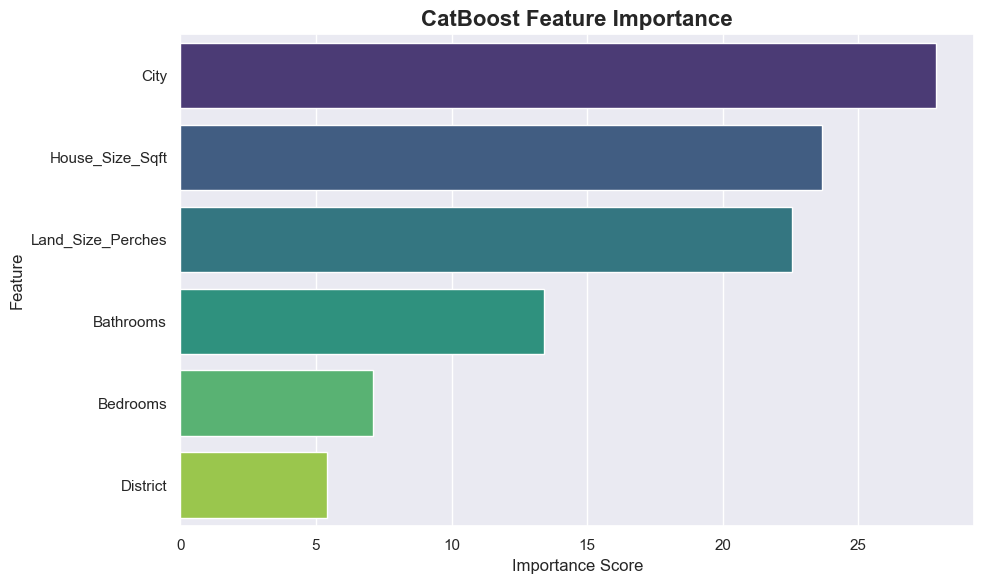

In [3]:
feature_importances = model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print('CatBoost Feature Importance:')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('CatBoost Feature Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

- **City** is the most important feature — location is the #1 driver of property prices in Sri Lanka
- **House Size** and **Land Size** follow closely, which makes physical sense
- **Bathrooms** outweigh **Bedrooms** — more bathrooms signal luxury/higher-end properties
- **District** has relatively lower importance since City already captures location granularity

## 3. SHAP Analysis

SHAP values tell us how each feature contributes to an individual prediction. Positive SHAP values push the price higher; negative values push it lower.

In [4]:
# Use a subset for faster computation
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed for {len(X_shap)} samples.')
print(f'SHAP values shape: {shap_values.shape}')

SHAP values computed for 500 samples.
SHAP values shape: (500, 6)


### 3a. SHAP Summary Plot (Beeswarm)

Each dot represents one prediction. The x-axis shows the SHAP value (impact on price). Color indicates the feature value (red = high, blue = low).

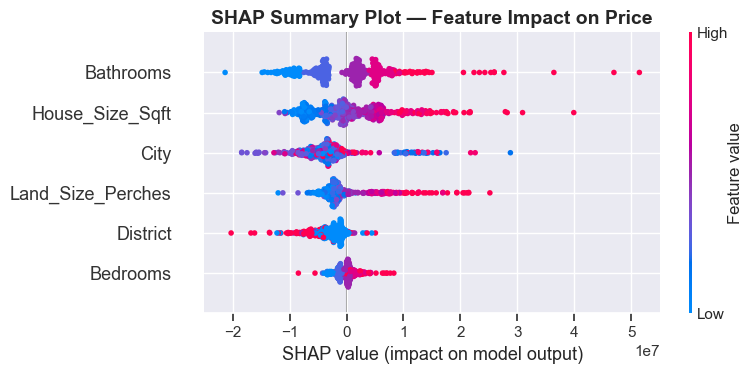

In [5]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_columns, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 3b. SHAP Bar Plot (Mean |SHAP|)

Shows the average absolute SHAP value for each feature — a global measure of feature importance from the SHAP perspective.

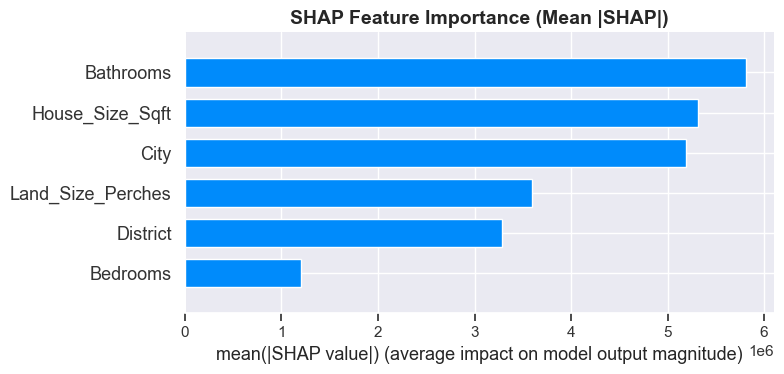

In [6]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=feature_columns, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### 3c. SHAP Dependence Plots

These show how a single feature's value affects the prediction, and how it interacts with other features.

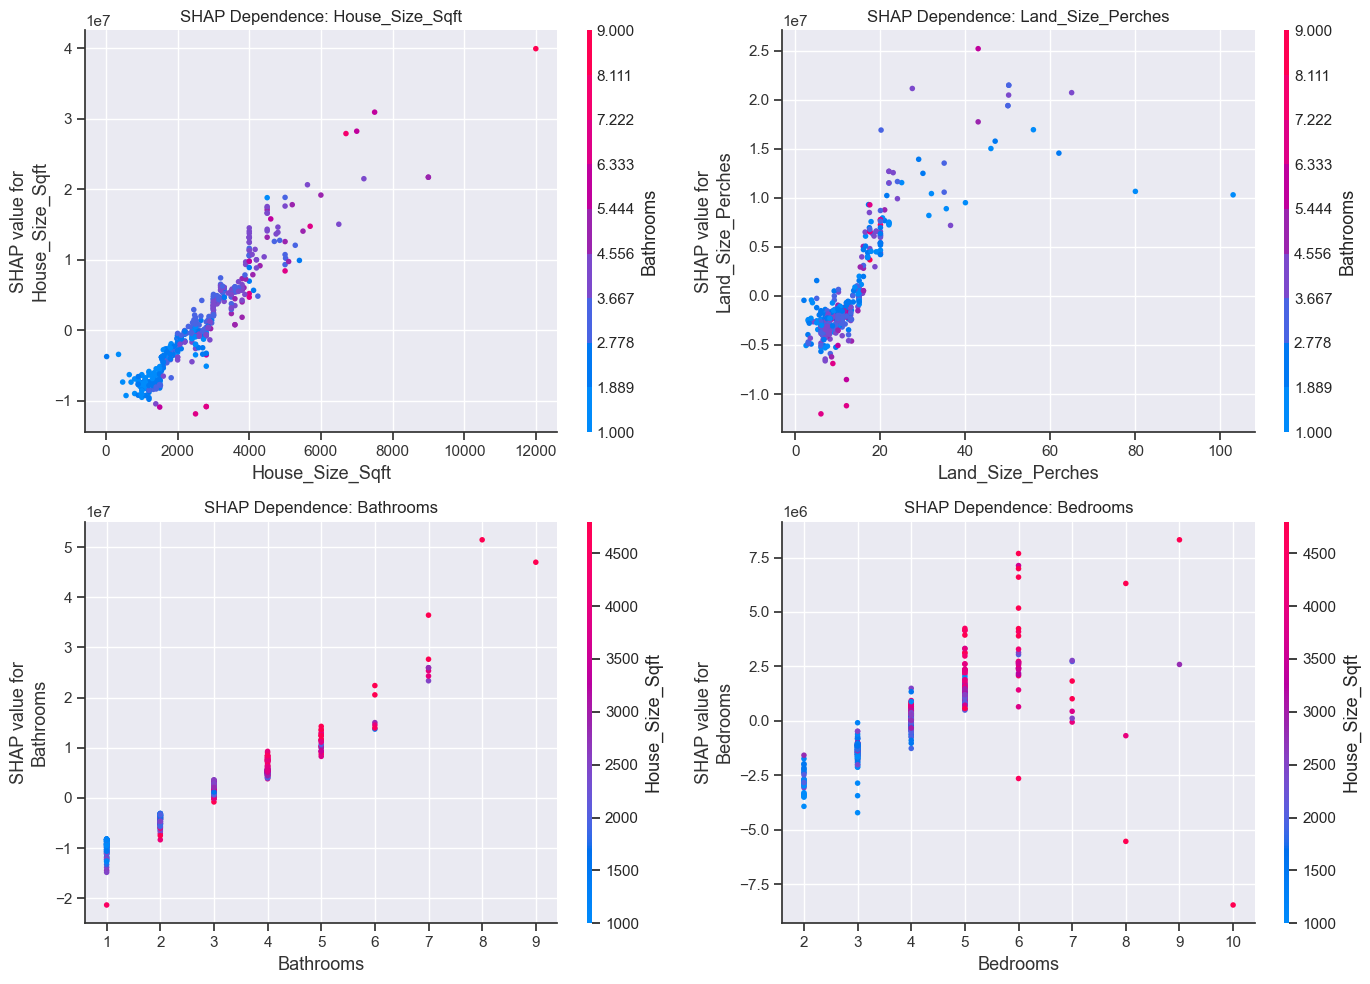

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (feat, ax) in enumerate(zip(['House_Size_Sqft', 'Land_Size_Perches', 'Bathrooms', 'Bedrooms'], axes.flatten())):
    feat_idx = feature_columns.index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_shap,
                         feature_names=feature_columns, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 3d. Individual Prediction Explanation

Let's explain a single prediction to understand how each feature contributes.

In [8]:
# Pick a random sample
sample_idx = 0
sample = X_shap.iloc[[sample_idx]]
predicted = model.predict(sample)[0]
actual = y_test.iloc[X_shap.index[sample_idx]]

print(f'Sample Property Features:')
for col in feature_columns:
    print(f'  {col}: {sample[col].values[0]}')
print(f'\nActual Price:    Rs. {actual:,.0f}')
print(f'Predicted Price: Rs. {predicted:,.0f}')
print(f'\nSHAP values for this prediction:')
for feat, sv in zip(feature_columns, shap_values[sample_idx]):
    direction = '↑' if sv > 0 else '↓'
    print(f'  {feat:<25} {direction} {sv/1e6:+.2f}M LKR')

Sample Property Features:
  Bedrooms: 4
  Bathrooms: 4
  Land_Size_Perches: 15.8
  House_Size_Sqft: 5000.0
  City: 169
  District: 18

Actual Price:    Rs. 87,500,000
Predicted Price: Rs. 53,938,492

SHAP values for this prediction:
  Bedrooms                  ↑ +0.56M LKR
  Bathrooms                 ↑ +9.00M LKR
  Land_Size_Perches         ↑ +0.27M LKR
  House_Size_Sqft           ↑ +17.62M LKR
  City                      ↓ -1.82M LKR
  District                  ↓ -4.81M LKR


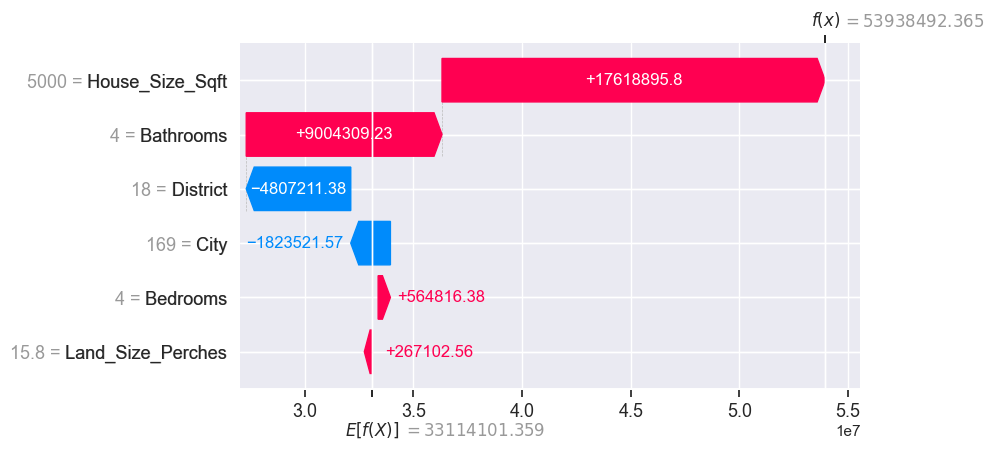

In [9]:
# Waterfall plot for individual prediction
shap.initjs()
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_idx].values,
    feature_names=feature_columns
)
shap.plots.waterfall(explanation, show=True)

## 4. Key XAI Insights

### What drives property prices up?
- **Premium locations** (certain cities in Colombo district)
- **Larger house size** (strong positive correlation)
- **More land** (bigger perch count)
- **More bathrooms** (signals luxury/quality)

### What keeps prices lower?
- **Rural/suburban locations** (lower city index)
- **Smaller houses** (<1000 sqft)
- **Fewer bathrooms** (1-2)

### Model Behavior
- The model correctly captures that **location is king** — same house size/beds in Colombo 7 vs a rural area has vastly different prices
- **Non-linear effects** are captured: going from 2→3 bathrooms has more impact than 5→6
- **Feature interactions**: large houses on small land plots (apartments/condos) are priced differently than similar-sized houses on large plots